# Concurvity, two ways

A model that sees both the calendar and a raw feature with its own seasonal cycle can't tell
"it's winter" from "this feature is doing its usual winter thing" — both look the same. It
copes by splitting credit between them in whatever way fits the training data, which only works
for as long as the feature's relationship to the calendar stays the same. The fix: give the
model the feature's *anomaly* against a seasonal normal instead of its raw value, so there's
nothing left for the calendar terms to fight over.

Two ways that relationship breaks, both real:
1. **Multi-year drought** — hydro's seasonal peak shifts *timing* (a policy change delays
   reservoir releases; low snowpack years melt earlier).
2. **Electrification** — heat pump and AC adoption grows, so electric heating/cooling load's
   seasonal swing gets *bigger* — same timing, wider amplitude.

One important negative result first: a rising *sensitivity* to weather (more responsive demand,
same relationship to the calendar) is **not** a concurvity problem — provably so, and checked
below. Only a change in the feature's own relationship to the calendar is.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import ElasticNetCV, LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error
from xgboost import XGBRegressor

RNG = np.random.default_rng(0)
plt.rcParams["figure.figsize"] = (9, 3.6)
plt.rcParams["axes.spines.top"] = plt.rcParams["axes.spines.right"] = False
PURPLE, GREEN = "#8172B2", "#55A868"
fourier_cols = ["sin1", "cos1", "sin2", "cos2"]
burn_in_years, train_years, test_years = 4, 5, 3
shift_year = burn_in_years + train_years

## Shared machinery

One simulator, one feature builder, one pair of models. `shift` controls *what* changes at the
test boundary: `"phase"` moves X's seasonal peak, `"amplitude"` widens it, `"beta"` (the
negative-result check) only changes the sensitivity of price to X's anomaly.

In [2]:
def simulate(shift, seed=0):
    rng = np.random.default_rng(seed)
    n_days = int((burn_in_years + train_years + test_years) * 365.25)
    dates = pd.date_range("2012-01-01", periods=n_days, freq="D")
    t = (dates - dates[0]).days / 365.25
    post = t >= shift_year

    demand_effect = 12 * np.sin(2 * np.pi * t) + 6 * np.cos(2 * np.pi * t)  # GBP/MWh, never changes
    phase = np.where(post & (shift == "phase"), 0.60, 0.30)
    amp = np.where(post & (shift == "amplitude"), 6.0, 3.0)
    beta = np.where(post & (shift == "beta"), -6.0, -3.0)
    seasonal_X = amp * np.sin(2 * np.pi * (t + phase))

    rho, sigma_innov = 0.97, 0.5
    anomaly_X = np.empty(n_days); anomaly_X[0] = 0.0
    innov = rng.normal(0, sigma_innov, n_days)
    for i in range(1, n_days):
        anomaly_X[i] = rho * anomaly_X[i - 1] + innov[i]

    X = 6.0 + seasonal_X + anomaly_X + rng.normal(0, 0.2, n_days)
    price = 70.0 + demand_effect + beta * anomaly_X + rng.normal(0, 4.0, n_days)

    df = pd.DataFrame({"t_years": t, "X": X, "price": price}, index=dates)
    df["doy"], df["year"] = df.index.dayofyear, df.index.year
    for i in [1, 2]:
        df[f"sin{i}"] = np.sin(2 * np.pi * i * df["t_years"])
        df[f"cos{i}"] = np.cos(2 * np.pi * i * df["t_years"])
    return df

def build_anomaly_feature(df):
    df = df.copy()
    df["climatology"] = np.nan
    for i, yr in enumerate(sorted(df["year"].unique())):
        if i == 0:
            continue
        hist = df[df["year"] < yr]
        clim = LinearRegression().fit(hist[fourier_cols], hist["X"])
        mask = df["year"] == yr
        df.loc[mask, "climatology"] = clim.predict(df.loc[mask, fourier_cols])
    df["climatology"] = df["climatology"].bfill()
    df["X_anomaly"] = df["X"] - df["climatology"]
    return df

def fit_enet(train_df, cols):
    m = make_pipeline(StandardScaler(), ElasticNetCV(l1_ratio=[.1, .5, .9, 1], cv=5, random_state=0, max_iter=10000))
    return m.fit(train_df[cols], train_df["price"])

def fit_xgb(train_df, cols):
    m = XGBRegressor(n_estimators=300, max_depth=3, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, random_state=0)
    return m.fit(train_df[cols], train_df["price"])

def run_story(shift, seed=0):
    df = build_anomaly_feature(simulate(shift, seed))
    train = df[(df["t_years"] >= burn_in_years) & (df["t_years"] < shift_year)]
    test = df[df["t_years"] >= shift_year]
    features_raw, features_anom = fourier_cols + ["X"], fourier_cols + ["X_anomaly"]
    models = {
        "ElasticNet - raw": (fit_enet(train, features_raw), features_raw),
        "ElasticNet - anomaly": (fit_enet(train, features_anom), features_anom),
        "XGBoost - raw": (fit_xgb(train, features_raw), features_raw),
        "XGBoost - anomaly": (fit_xgb(train, features_anom), features_anom),
    }
    rmse = {name: mean_squared_error(test["price"], m.predict(test[cols])) ** 0.5 for name, (m, cols) in models.items()}
    return df, train, test, rmse

def plot_result(df, rmse, title):
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
    axes[0].plot(df.index, df["X"], lw=0.5, color=PURPLE)
    axes[0].axvline(df[df["t_years"] >= shift_year].index.min(), color="k", ls="--", lw=1)
    axes[0].set_title("raw feature")
    names = list(rmse)
    axes[1].bar(names, [rmse[n] for n in names], color=[PURPLE, GREEN, PURPLE, GREEN])
    axes[1].set_title(f"test RMSE — {title}")
    plt.setp(axes[1].get_xticklabels(), rotation=20, ha="right")
    fig.tight_layout()
    plt.show()

## Story 1 — multi-year drought (timing shifts)

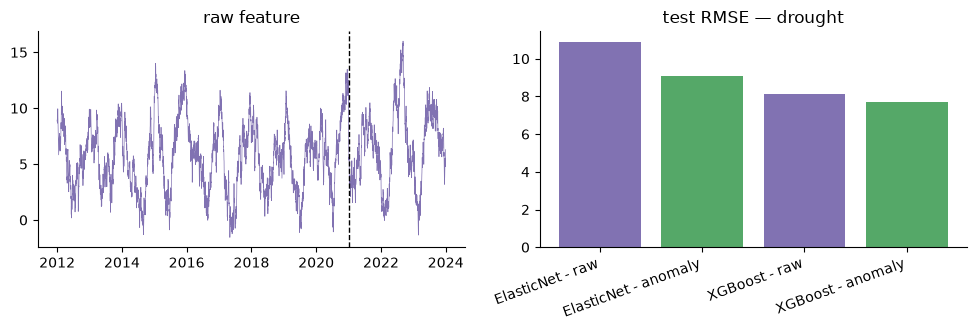

ElasticNet - raw        10.91
ElasticNet - anomaly     9.08
XGBoost - raw            8.11
XGBoost - anomaly        7.72
dtype: float64


In [3]:
df1, train1, test1, rmse1 = run_story("phase")
plot_result(df1, rmse1, "drought")
print(pd.Series(rmse1).round(2))

## Story 2 — electrification (amplitude widens)

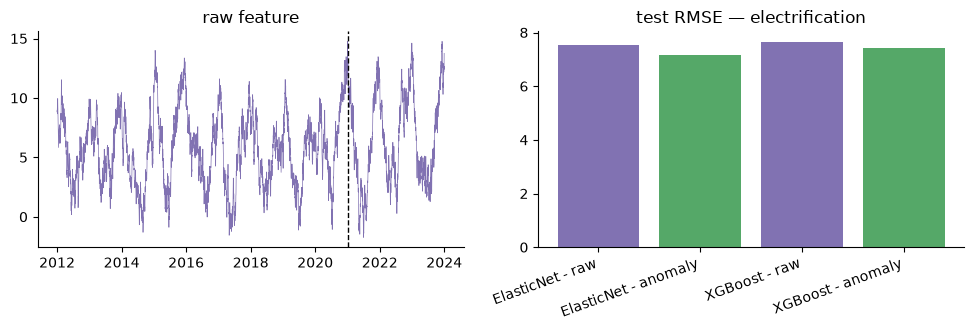

ElasticNet - raw        7.54
ElasticNet - anomaly    7.17
XGBoost - raw           7.66
XGBoost - anomaly       7.44
dtype: float64


In [4]:
df2, train2, test2, rmse2 = run_story("amplitude")
plot_result(df2, rmse2, "electrification")
print(pd.Series(rmse2).round(2))

## The negative result — sensitivity alone doesn't count

In [5]:
df3, train3, test3, rmse3 = run_story("beta")
print(pd.Series(rmse3).round(2))

ElasticNet - raw        7.52
ElasticNet - anomaly    8.04
XGBoost - raw           8.88
XGBoost - anomaly       9.08
dtype: float64


Same size of change, same test window — but here only the *coefficient* on X's anomaly rises,
not X's relationship to the calendar. The raw model does not get worse relative to the anomaly
model. That's not a coincidence: algebraically, the calendar terms can absorb any fixed multiple
of X's seasonal shape, whatever that multiple is — so the compensation trick that makes raw
features fragile is completely indifferent to how strongly X's effect is weighted. It only
breaks when X's *own* seasonal timing or amplitude moves. A rising sensitivity to weather is a
real business problem, but it isn't this one, and deseasonalizing X doesn't fix it.

## Conclusion

Same failure, two real causes, one fix, one thing the fix doesn't do. Concurvity bites when the
raw feature's *own* relationship to the calendar changes — a shift in timing or amplitude — and
an anomaly feature, refreshed each year without retraining the model, rides that out. It has
nothing to offer against a feature whose effect on the target simply gets stronger or weaker;
that needs the coefficient itself to be re-estimated, not the feature re-engineered.